# Phase 7 — Pretrain

Teach the model English before asking it to translate. Phase 4 failed because 474k words cannot teach language *and* a style mapping at once; this run supplies ~200M words.

**Kaggle settings — both required:**
- **Accelerator: GPU** (T4 or P100)
- **Internet: ON** — needed to clone the repo and stream Gutenberg

In [1]:
import os, subprocess, sys, time

REPO = "https://github.com/Amay-M-Nair/AttentionMech.git"
ON_KAGGLE = os.path.isdir("/kaggle")
ROOT = "/kaggle/working/AttentionMech" if ON_KAGGLE else os.path.dirname(os.getcwd())

if ON_KAGGLE and not os.path.isdir(ROOT):
    subprocess.run(["git", "clone", "--depth", "1", REPO, ROOT], check=True)

sys.path.insert(0, ROOT)

for pkg in ("sentencepiece", "datasets", "sacrebleu"):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
print("root:", ROOT)

Cloning into '/kaggle/working/AttentionMech'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 8.0 MB/s eta 0:00:00
torch 2.10.0+cu128 | cuda True
gpu: Tesla T4 | 16 GB
root: /kaggle/working/AttentionMech


## 1. Tokenise the corpus

Stream Gutenberg, tokenise once, write a flat `uint16` file. Doing it once means later epochs cost nothing and the dataloader never touches the network.

`MAX_WORDS` is the knob: 200M is the planned run, drop it to 20M for a quick end-to-end test.

In [2]:
from src.corpus import stream_gutenberg, build_token_file, TokenFileDataset
from src.spm_tokenizer import SPMTokenizer

DATA = os.path.join(ROOT, "data")
TOKENS = "/kaggle/working/tokens.bin" if ON_KAGGLE else os.path.join(DATA, "tokens.bin")
MAX_WORDS = 200_000_000

tokenizer = SPMTokenizer(os.path.join(DATA, "spm32k.model"))
print("vocab:", len(tokenizer))

if not os.path.exists(TOKENS):
    t0 = time.time()
    n = build_token_file(stream_gutenberg(max_words=MAX_WORDS, progress_every=500),
                         tokenizer, TOKENS)
    print(f"{n/1e6:.1f}M tokens in {(time.time()-t0)/60:.1f} min")
else:
    print("token file already present")

print(f"{os.path.getsize(TOKENS)/1e6:.0f} MB")

vocab: 32000


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

     0.0M tokens
     5.1M tokens
    10.0M tokens
    15.0M tokens
    20.0M tokens
    25.1M tokens
    30.0M tokens
    35.0M tokens
    40.0M tokens
    45.1M tokens
    50.6M tokens
    55.1M tokens
     500 books     38.8M words
    60.1M tokens
    65.2M tokens
    70.2M tokens
    75.1M tokens
    80.1M tokens
    85.1M tokens
    90.1M tokens
    95.1M tokens
   100.0M tokens
    1000 books     72.2M words
   105.0M tokens
   110.2M tokens
   115.1M tokens
   120.1M tokens
   125.1M tokens
   130.0M tokens
   135.0M tokens
   140.0M tokens
    1500 books    102.2M words
   145.0M tokens
   150.0M tokens
   155.1M tokens
   160.1M tokens
   165.1M tokens
   170.0M tokens
   175.0M tokens
   180.1M tokens
   185.1M tokens
    2000 books    137.1M words
   190.0M tokens
   195.6M tokens
   200.0M tokens
   205.1M tokens
   210.1M tokens
   215.2M tokens
   220.1M tokens
   226.1M tokens
   230.2M tokens
   235.1M tokens
    2500 books    174.4M words
   240.2M tokens
   245.1M to

Check the tokens decode back to English before training on them.

In [3]:
SEQ_LEN = 256
tokens = TokenFileDataset(TOKENS, seq_len=SEQ_LEN)
print(f"{len(tokens):,} windows of {SEQ_LEN}")
print()
print(tokenizer.decode(tokens[0])[:300])

1,063,307 windows of 256

The United States Bill of Rights. The Ten Original Amendments to the Constitution of the United States Passed by Congress September 25, 1789 Ratified December 15, 1791 I Congress shall make no law respecting an establishment of religion, or prohibiting the free exercise thereof; or abridging the fre


## 2. Span corruption

Mask 15% of tokens in spans of mean length 3. The encoder sees sentinels in place of the spans; the decoder reconstructs them. Filling those blanks is what teaches word meanings and syntax.

In [4]:
from torch.utils.data import DataLoader
from src.dataset import collate_fn
from src.denoising import DenoisingDataset

BATCH = 32          # T4 16 GB; drop to 16 with ACCUMULATE 2 if OOM
ACCUMULATE = 1

dataset = DenoisingDataset(tokens, tokenizer.sentinel_ids)
loader = DataLoader(dataset, batch_size=BATCH, shuffle=True,
                    collate_fn=collate_fn, num_workers=2, drop_last=True)

src, tgt_in, tgt_out = next(iter(loader))
print("src    ", tuple(src.shape))
print("tgt_in ", tuple(tgt_in.shape))
print("tgt_out", tuple(tgt_out.shape))
print()
print("encoder:", tokenizer.decode(src[0], keep_specials=True)[:220])
print()
print("decoder:", tokenizer.decode(tgt_out[0], keep_specials=True)[:220])

src     (32, 232)
tgt_in  (32, 53)
tgt_out (32, 53)

encoder: —respect for their worth and admiration of their talents. You too have principle and mind: your tastes and habits resemble Diana’s and<extra_id_0>’s; your presence is always agreeable to me; in your conversation I have a

decoder: <extra_id_0> Mary<extra_id_1> for some time found a salutary<extra_id_2>.<extra_id_3> sister.”<extra_id_4>Thank you:<extra_id_5> had<extra_id_6> up<extra_id_7> “<extra_id_8> he took leave. I need not<extra_id_9> argument


## 3. The model

Same architecture as Phase 1 — scaling is a config change, nothing in `transformer.py` moves.

In [5]:
from src.config import TransformerConfig, get_device
from src.transformer import build_model

device = get_device()
torch.manual_seed(0)

config = TransformerConfig(vocab_size=len(tokenizer), d_model=384, num_heads=8,
                           num_layers=6, d_ff=1536, dropout=0.1, max_len=512)
model = build_model(config).to(device)

for name, count in model.count_parameters().items():
    print(f"  {name:<12} {count:>12,}")

  src_embed      12,288,000
  encoder        10,638,336
  decoder        14,181,888
  TOTAL          37,108,224


## 4. Gate — can it learn the objective?

Overfit a single batch. If it can't memorise one batch the corruption is wired wrong, and a full run would take an hour to tell you that.

A 37M model needs ~600 steps to get there. Expect roughly **loss 10.4 → 0.7, accuracy ~93%** — measured, not a guess.

In [6]:
from src.train import overfit_batch

probe = build_model(TransformerConfig(vocab_size=len(tokenizer), d_model=384, num_heads=8,
                                      num_layers=6, d_ff=1536, dropout=0.0, max_len=512)).to(device)
batch = tuple(t.to(device) for t in next(iter(loader)))

h = overfit_batch(probe, batch, steps=600, log_every=150)
print(f"\nloss {h['loss'][0]:.3f} -> {h['loss'][-1]:.4f}   acc {h['acc'][-1]:.1%}")
passed = h["loss"][-1] < 1.5 and h["acc"][-1] > 0.85
print("GATE:", "PASS" if passed else "FAIL - do not start the long run")
del probe
torch.cuda.empty_cache()

step     1   loss 10.4052   acc  0.0%
step   150   loss 3.8191   acc 29.0%
step   300   loss 2.4559   acc 55.5%
step   450   loss 1.2771   acc 86.8%
step   600   loss 0.6601   acc 94.0%

loss 10.405 -> 0.6601   acc 94.0%
GATE: PASS


## 5. Measure throughput before committing

Time estimates carry large error bars. 300 steps gives a real tokens/sec, and the full run length follows from it.

In [7]:
from src.train import pretrain

PROBE_CK = "/kaggle/working/_probe.pt" if ON_KAGGLE else os.path.join(ROOT, "checkpoints", "_probe.pt")
if os.path.exists(PROBE_CK):
    os.remove(PROBE_CK)

probe_history = pretrain(model, config, loader, device, steps=300, lr=3e-4, warmup=100,
                         accumulate=ACCUMULATE, log_every=100,
                         checkpoint_path=PROBE_CK, checkpoint_every=0, resume=False)

rate = probe_history["tokens_per_sec"][-1]
tokens_total = len(tokens) * SEQ_LEN
steps_per_epoch = tokens_total // (BATCH * ACCUMULATE * SEQ_LEN)

print(f"\n{rate/1000:.1f}k corpus tokens/sec")
print(f"corpus: {tokens_total/1e6:.0f}M tokens -> {steps_per_epoch:,} steps for one pass")
print(f"one pass: {tokens_total/rate/3600:.1f} h")
os.remove(PROBE_CK)

step     100/300  loss  8.374  ppl   4332.2   29.6k corpus tok/s  eta  0.0h
step     200/300  loss  5.746  ppl    312.9   30.9k corpus tok/s  eta  0.0h
step     300/300  loss  5.457  ppl    234.3   29.6k corpus tok/s  eta  0.0h

done -> /kaggle/working/_probe.pt

29.6k corpus tokens/sec
corpus: 272M tokens -> 33,228 steps for one pass
one pass: 2.6 h


## 6. The run

Set `STEPS` from the estimate above — one pass over the corpus is the target. More data at one epoch beats repeating less data.

Checkpoints carry optimizer and scheduler state, so a dead session resumes correctly. Re-running this cell picks up where it stopped.

In [8]:
STEPS = steps_per_epoch
CHECKPOINT = "/kaggle/working/pretrained.pt" if ON_KAGGLE else os.path.join(ROOT, "checkpoints", "pretrained.pt")

torch.manual_seed(0)
model = build_model(config).to(device)

history = pretrain(
    model, config, loader, device,
    steps=STEPS, lr=3e-4, warmup=2000,
    accumulate=ACCUMULATE, amp=True, log_every=200,
    checkpoint_path=CHECKPOINT, checkpoint_every=1000, resume=True,
)

step     200/33,228  loss  9.709  ppl  16467.0   30.9k corpus tok/s  eta  2.2h
step     400/33,228  loss  7.342  ppl   1544.2   30.5k corpus tok/s  eta  2.2h
step     600/33,228  loss  5.813  ppl    334.5   28.3k corpus tok/s  eta  2.4h
step     800/33,228  loss  5.412  ppl    224.1   25.3k corpus tok/s  eta  2.6h
step   1,000/33,228  loss  5.327  ppl    205.7   26.7k corpus tok/s  eta  2.5h
step   1,200/33,228  loss  5.262  ppl    192.8   24.4k corpus tok/s  eta  2.7h
step   1,400/33,228  loss  5.182  ppl    178.0   27.6k corpus tok/s  eta  2.4h
step   1,600/33,228  loss  5.098  ppl    163.6   30.2k corpus tok/s  eta  2.2h
step   1,800/33,228  loss  5.035  ppl    153.8   28.6k corpus tok/s  eta  2.3h
step   2,000/33,228  loss  4.986  ppl    146.4   31.2k corpus tok/s  eta  2.1h
step   2,200/33,228  loss  4.958  ppl    142.4   27.8k corpus tok/s  eta  2.3h
step   2,400/33,228  loss  4.931  ppl    138.5   29.8k corpus tok/s  eta  2.1h
step   2,600/33,228  loss  4.910  ppl    135.6   28.

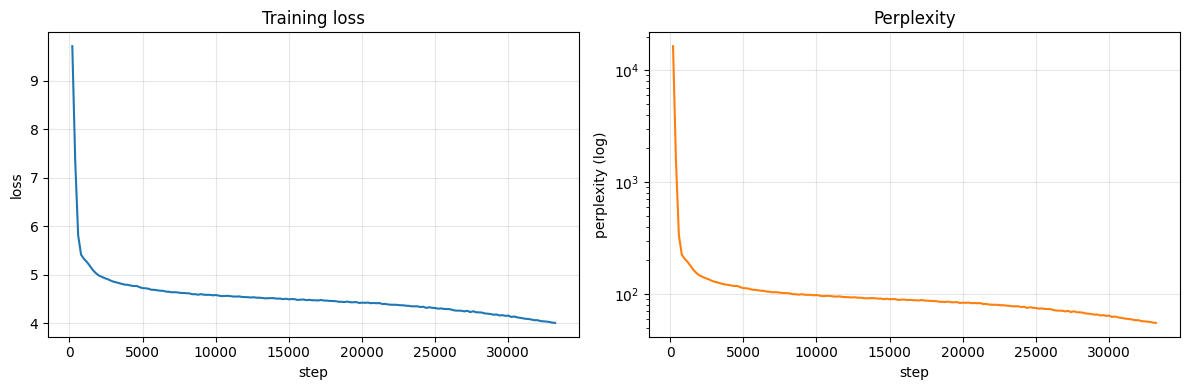

final loss 4.007   perplexity 55.0
random baseline would be 32,000


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["step"], history["loss"])
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.3)
axes[0].set_title("Training loss")

axes[1].plot(history["step"], history["perplexity"], color="tab:orange")
axes[1].set_yscale("log")
axes[1].set_xlabel("step"); axes[1].set_ylabel("perplexity (log)"); axes[1].grid(alpha=0.3)
axes[1].set_title("Perplexity")
plt.tight_layout(); plt.show()

print(f"final loss {history['loss'][-1]:.3f}   perplexity {history['perplexity'][-1]:.1f}")
print(f"random baseline would be {len(tokenizer):,}")

## 7. Gate — did it learn English?

Perplexity falling is necessary but not sufficient. Mask a span in a sentence the model has never seen and read what it fills in.

In [10]:
from src.inference import greedy_decode
from src.dataset import load_split
from src.denoising import corrupt_spans
import numpy as np

held_out, _ = load_split(DATA, "test")
rng = np.random.default_rng(0)
model.eval()

for line in held_out[:6]:
    ids = tokenizer.encode(line)
    if len(ids) < 12:
        continue
    enc, _ = corrupt_spans(ids, tokenizer.sentinel_ids, rng=rng)
    src_t = torch.tensor([enc + [2]], device=device)
    out = greedy_decode(model, src_t, max_len=48)

    print("masked :", tokenizer.decode(enc, keep_specials=True))
    print("filled :", tokenizer.decode(out[0], keep_specials=True))
    print("truth  :", line)
    print()

masked : Riddling confession finds but riddling<extra_id_0>
filled : <extra_id_0>,<extra_id_1>,<extra_id_2>,<extra_id_3>,<extra_id_4>,<extra_id_5>,<extra_id_6>,<extra_id_7>,<extra_id_8>,<extra_id_9>,<extra_id_10>,<extra_id_11>, and<extra_id_12>, and the other's work. The first thing was the same. The first thing was the first of
truth  : Riddling confession finds but riddling shrift .

masked : Then plainly know my heart's dear love is set On the fair daughter of<extra_id_0>
filled : <extra_id_0> her<extra_id_1> her<extra_id_2>.<extra_id_3> and<extra_id_4>.<extra_id_5> her<extra_id_6> her<extra_id_7> her<extra_id_8> her<extra_id_9>. She<extra_id_10> and her mother's daughter. She is a woman of her father's daughter, and<extra_id_11>, and<extra_id_12> and she is
truth  : Then plainly know my heart's dear love is set On the fair daughter of rich Capulet .

masked : As mine on hers , so hers is set on mine , And all combined , save what thou must combine<extra_id_0>
filled : <extra_id_0>,

## Done

`pretrained.pt` now holds a model that knows English. Download it from the Kaggle output panel — Phase 8 loads it with `load_pretrained()` and fine-tunes on the 18k Shakespeare pairs.

The target there: **beat 19.22**, the copy baseline that Phase 4 scored 15.07 against.